In [76]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("../images",exist_ok = True)
#style
sns.set_style("darkgrid")

#load dataset
df = pd.read_csv("../data/WHO-COVID-19-global-data.csv")

#show first rows
df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AW,Aruba,AMRO,NaN,0,NaN,0
1,2020-01-12,AW,Aruba,AMRO,NaN,0,NaN,0
2,2020-01-19,AW,Aruba,AMRO,NaN,0,NaN,0
3,2020-01-26,AW,Aruba,AMRO,NaN,0,NaN,0
4,2020-02-02,AW,Aruba,AMRO,NaN,0,NaN,0


In [77]:
#check missing values
df.isnull().sum()

Date_reported            0
Country_code           329
Country                  0
WHO_region            5922
New_cases            27442
Cumulative_cases         0
New_deaths           42152
Cumulative_deaths        0
dtype: int64

In [78]:
#dataset info 
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 78960 entries, 0 to 78959
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date_reported      78960 non-null  str    
 1   Country_code       78631 non-null  str    
 2   Country            78960 non-null  str    
 3   WHO_region         73038 non-null  str    
 4   New_cases          51518 non-null  float64
 5   Cumulative_cases   78960 non-null  int64  
 6   New_deaths         36808 non-null  float64
 7   Cumulative_deaths  78960 non-null  int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 4.8 MB


In [79]:
#convert date column
df["Date_reported"]= pd.to_datetime(df["Date_reported"])


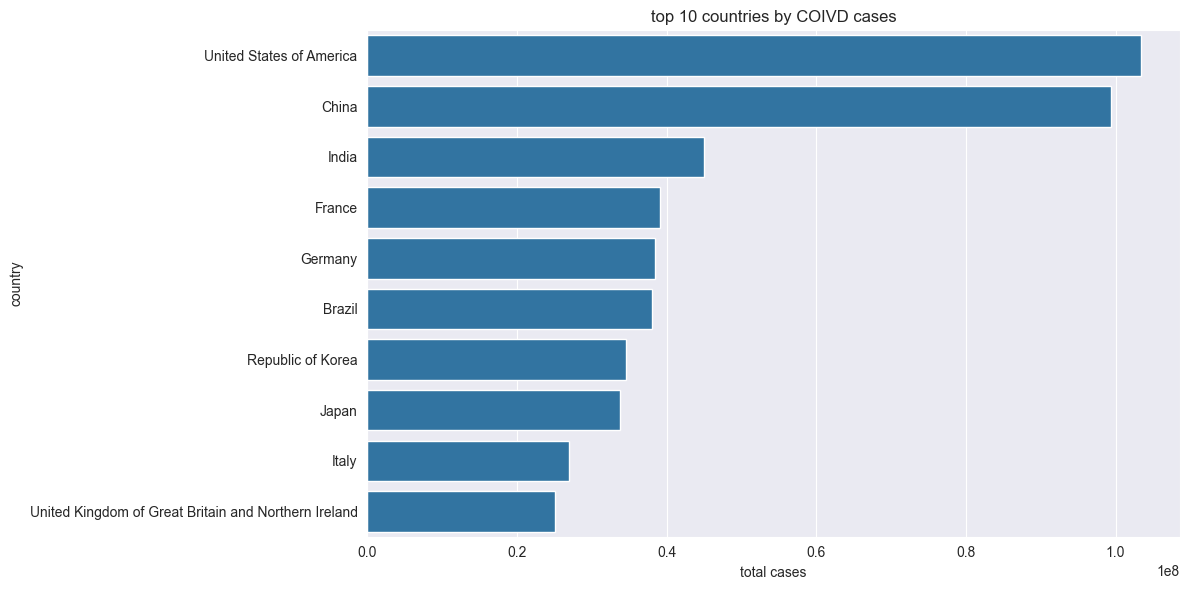

In [80]:
#TOP 10 COUNTRIES BY TOTAL CASES 
top_cases = (df.groupby("Country")["Cumulative_cases"]
.max()
.sort_values(ascending = False)
.head(10)
)

top_cases

#VISUALIZATION
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cases.values,
    y=top_cases.index
)

plt.title("top 10 countries by COIVD cases")
plt.xlabel("total cases")
plt.ylabel("country")


plt.tight_layout()
plt.savefig("../images/top10_cases.png")
plt.show()

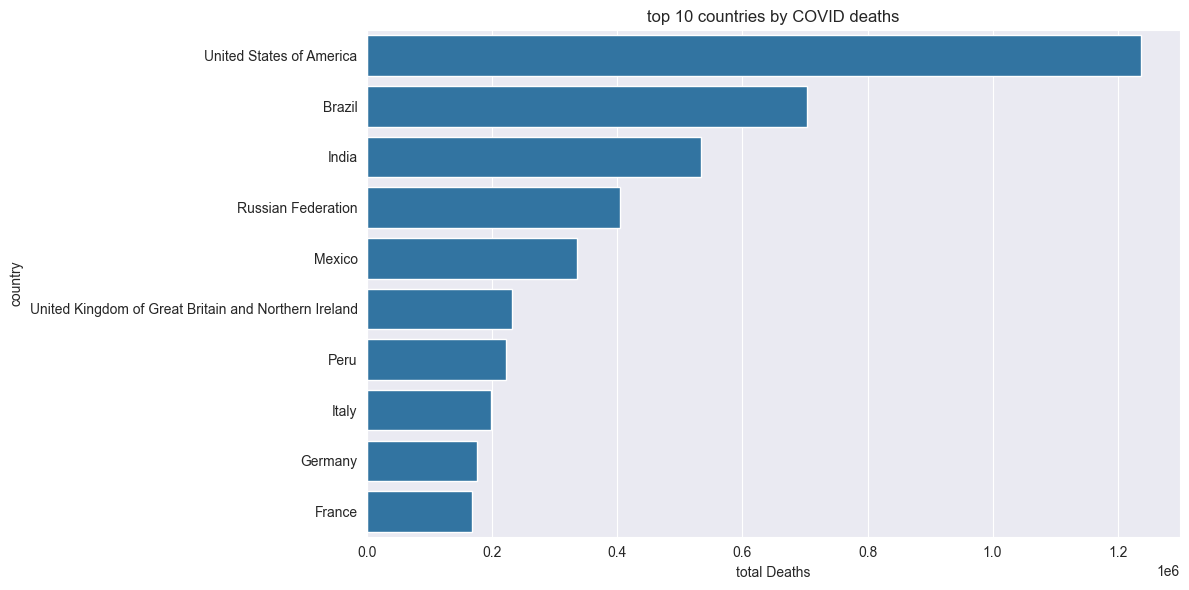

In [81]:
#TOP 10 COUNTRIES BY DEATH
top_deaths = (
    df.groupby("Country")["Cumulative_deaths"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

top_deaths

#VISUALIZATION
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_deaths.values,
    y=top_deaths.index
)

plt.title("top 10 countries by COVID deaths")
plt.xlabel("total Deaths")
plt.ylabel("country")

plt.tight_layout()

plt.savefig("../images/top10_death.png")

plt.show()



In [ ]:
#MONTHLY GLOBAL CASE TRENDS
monthly_cases =( 
df.groupby(df["Date_reported"].dt.to_period("M"))["New_cases"].sum())

monthly_cases.index = monthly_cases.index.astype(str)
monthly_cases.head()

#VISUALIZATION
plt.figure(figsize=(14,6))
plt.plot(
    monthly_cases.index,
    monthly_cases.values
)

plt.xticks(rotation=90)
plt.title("monthly global covid cases trendds")
plt.xlabel("month")
plt.ylabel("new cases")

plt.tight_layout()

plt.savefig("../images/monthly_trends.png")

plt.show()


KeyError: 'Column not found: new_cases'